# **ML Project on Stock Price**

### **Introduction**

The ADANIPORTS dataset contains historical stock market data of Adani Ports and Special Economic Zone, including features such as opening price, closing price, highest price, lowest price, trading volume, and date-wise stock information. This dataset is widely used for financial data analysis, trend identification, and predictive modeling in the stock market domain.

In this project, Exploratory Data Analysis (EDA) is performed using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to understand the structure, patterns, trends, and relationships present in the dataset. Various visualizations are used to analyze stock price movement, trading volume, volatility, correlations, and market behavior over time.

Furthermore, Machine Learning techniques such as Linear Regression and Polynomial Regression are applied to predict stock prices and analyze trends based on historical data. Linear Regression helps identify the linear relationship between variables, while Polynomial Regression captures non-linear patterns and complex market trends more effectively.

The main objective of this project is to gain meaningful insights from stock market data and understand how data analysis and regression models can be used for financial forecasting and prediction.

### **Import Necessary Libraries**

In [1]:
#remove warning messages
import warnings
warnings.filterwarnings('ignore')

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

### **Import Dataset**

In [2]:
df = pd.read_csv("ADANIPORTS.csv")

### **Display the first 5 rows**

In [3]:
df.head(5)

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


### **Dispaly the last 5 rows**

In [4]:
df.tail(5)

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
3317,2021-04-26,ADANIPORTS,EQ,725.35,733.0,739.65,728.90,729.2,730.75,733.25,9390549,6.885658e+14,116457.0,838079,0.0892
3318,2021-04-27,ADANIPORTS,EQ,730.75,735.0,757.50,727.35,748.6,749.15,747.67,20573107,1.538191e+15,236896.0,1779639,0.0865
3319,2021-04-28,ADANIPORTS,EQ,749.15,755.0,760.00,741.10,743.4,746.25,751.02,11156977,8.379106e+14,130847.0,1342353,0.1203
3320,2021-04-29,ADANIPORTS,EQ,746.25,753.2,765.85,743.40,746.4,746.75,753.06,13851910,1.043139e+15,153293.0,1304895,0.0942
3321,2021-04-30,ADANIPORTS,EQ,746.75,739.0,759.45,724.50,726.4,730.05,743.35,12600934,9.366911e+14,132141.0,3514692,0.2789


### **Data Cleaning**

In [5]:
#Convert column name to standard type

df.columns = (df.columns
              .str.strip()
              .str.title()
              .str.replace(" ","_")
              .str.replace("-","_")
              .str.replace("%","")
              )

In [6]:
#Convert date columns to date format

df['Date'] = pd.to_datetime(df['Date'])

In [7]:
#Check whether there is missing values

print(df.isnull().sum())

Date                    0
Symbol                  0
Series                  0
Prev_Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
Vwap                    0
Volume                  0
Turnover                0
Trades                866
Deliverable_Volume      0
Deliverble              0
dtype: int64


In [8]:
#Percentage of Missing values
missing_percent = (df['Trades'].isnull().sum() / len(df)) * 100
print(f"Missing Values: {missing_percent:.2f}%")

Missing Values: 26.07%


In [9]:
#Filling missing value with mediam
df['Trades'] = df['Trades'].fillna(df['Trades'].median())

In [10]:
#Check for duplicate values
df.duplicated().sum()

0

In [11]:
#Drop column which is not at all necessary
df.drop(columns=['Series'] ,inplace=True) #series column has same value EQ

### **Data Understanding**

In [12]:
#Basic Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3322 entries, 0 to 3321
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                3322 non-null   datetime64[ns]
 1   Symbol              3322 non-null   object        
 2   Prev_Close          3322 non-null   float64       
 3   Open                3322 non-null   float64       
 4   High                3322 non-null   float64       
 5   Low                 3322 non-null   float64       
 6   Last                3322 non-null   float64       
 7   Close               3322 non-null   float64       
 8   Vwap                3322 non-null   float64       
 9   Volume              3322 non-null   int64         
 10  Turnover            3322 non-null   float64       
 11  Trades              3322 non-null   float64       
 12  Deliverable_Volume  3322 non-null   int64         
 13  Deliverble          3322 non-null   float64     

In [13]:
# Use summary statistics to understand distribution
df.describe()

,Prev_Close,Open,High,Low,Last,Close,Vwap,Volume,Turnover,Trades,Deliverable_Volume,Deliverble
count,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3322.000000,3.322000e+03,3.322000e+03,3.322000e+03,3.322000e+03,3322.000000
mean,344.114314,344.763019,351.608007,337.531969,344.239539,344.201626,344.853182,2.954564e+06,1.070144e+14,4.256570e+04,1.207441e+06,0.445899
std,192.936882,193.619992,198.617808,188.676614,193.187813,193.045886,193.841305,4.104227e+06,2.625564e+14,4.337026e+04,1.398640e+06,0.160496
min,108.000000,108.000000,110.450000,105.650000,108.000000,108.000000,108.340000,1.236600e+04,2.415857e+11,3.660000e+02,5.383000e+03,0.067000
25%,164.312500,164.850000,168.000000,161.600000,164.075000,164.312500,164.855000,7.493682e+05,1.817650e+13,2.643650e+04,3.212005e+05,0.332900
50%,324.700000,325.750000,331.275000,319.850000,325.000000,324.700000,325.765000,2.007292e+06,5.836041e+13,3.588150e+04,8.132775e+05,0.445650
75%,400.912500,401.000000,407.187500,395.000000,400.912500,400.912500,400.607500,3.636883e+06,1.158526e+14,4.585475e+04,1.605528e+06,0.555850
max,1307.450000,1310.250000,1324.000000,1270.000000,1308.000000,1307.450000,1302.150000,9.771788e+07,8.160988e+15,1.205984e+06,2.241652e+07,0.979800


## **Data Analysis and Visualization**

1. How has the stock's closing price changed over time?

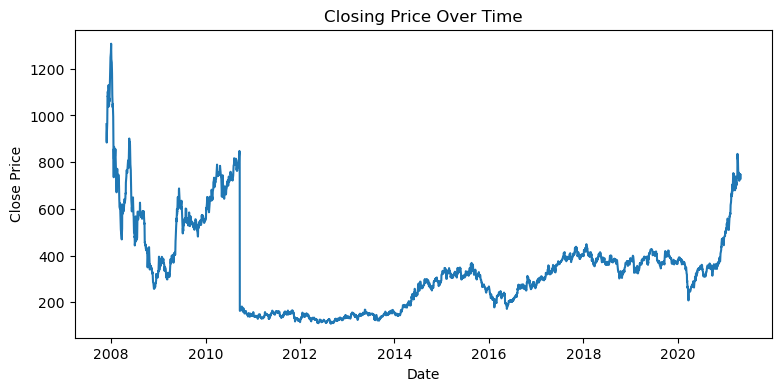

In [14]:
# Closing price trend
plt.figure(figsize=(9, 4))

# Line chart
plt.plot(df['Date'], df['Close'])

# Chart title and labels
plt.title("Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")

# Display chart
plt.show()

The line chart above shows how the closing price of ADANIPORTS changed over time.
An upward trend indicates growth in stock value, while downward movement indicates decline.
Sudden spikes or drops represent major market movements and investor reactions.
Overall trend analysis helps understand long-term stock performance.

2. What is the average closing price of the stock?

Average Closing Price: 344.2016255267911


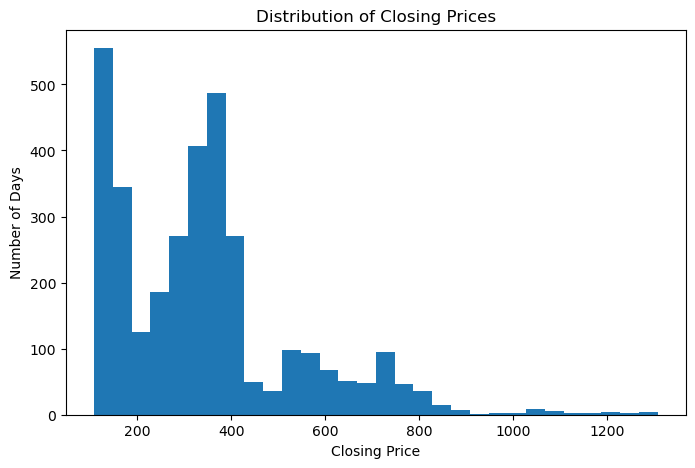

In [15]:
average_close = df['Close'].mean()
print("Average Closing Price:", average_close)

plt.figure(figsize=(8,5))
plt.hist(df['Close'], bins=30)
plt.xlabel('Closing Price')
plt.ylabel('Number of Days')
plt.title('Distribution of Closing Prices')
plt.show()

The average closing price provides a general representation of the stock's price during the analyzed period. The distribution shows where most of the closing prices are concentrated and whether the stock experienced unusually high or low price levels.

3. What is the daily percentage return of the stock?

0         NaN
1   -7.165853
2   -1.085133
3    4.224157
4    5.181488
Name: Close, dtype: float64


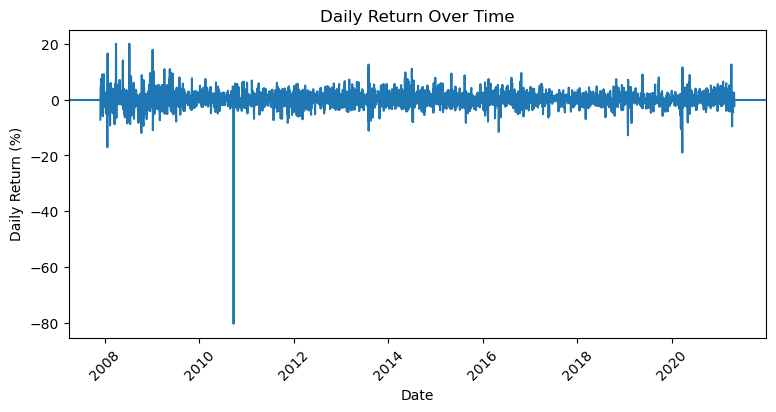

In [16]:
# Calculate daily return (%)
Daily_Return = df['Close'].pct_change() * 100

# Display first 5 values
print(Daily_Return.head())

# Create figure
plt.figure(figsize=(9, 4))

# Line chart
plt.plot(df['Date'], Daily_Return)

# Chart title and labels
plt.axhline(0)
plt.title('Daily Return Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.xticks(rotation=45)

# Display chart
plt.show()

Daily return analysis helps measure day-to-day profit or loss percentage.
Positive values indicate gain, while negative values indicate loss.
The histogram shows that most daily returns are concentrated around small percentage changes.
Extreme values indicate highly volatile trading days.

What is the relationship between each numerical columns in the dataset?

3: What is the relationship between Open, High, Low, Close, and Volume?

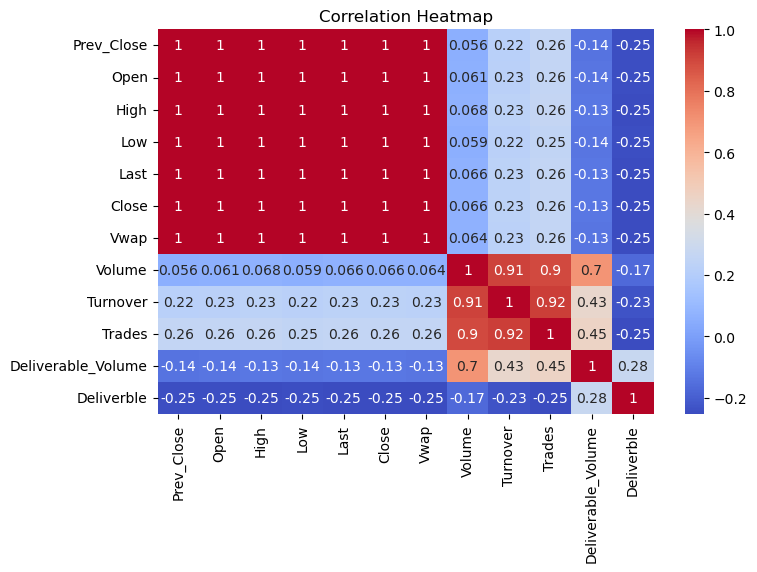

In [17]:
# Correlation matrix
correlation = df.corr(numeric_only=True)
#correlation = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows relationships between stock features.
Open, High, Low, and Close prices are usually highly positively correlated.
Volume may have weaker correlation compared to price columns.
Strong correlation indicates that stock prices move together consistently.

4: What are the short-term and long-term stock trends using Moving Averages?

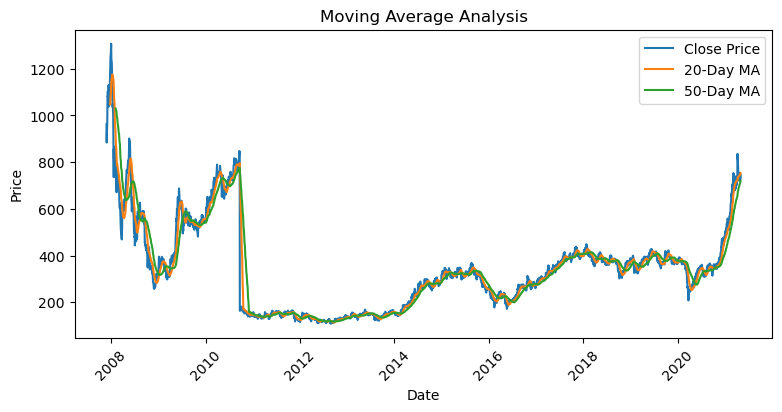

In [18]:
# Calculate moving averages
MA20 = df['Close'].rolling(window=20).mean()
MA50 = df['Close'].rolling(window=50).mean()

# Create figure
plt.figure(figsize=(9,4))

# Plot price and moving averages
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], MA20, label='20-Day MA')
plt.plot(df['Date'], MA50, label='50-Day MA')

# Chart title and labels
plt.title('Moving Average Analysis')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)

# Display chart
plt.show()

Moving averages smooth out short-term fluctuations in stock prices.
The 20-day moving average represents short-term trend.
The 50-day moving average represents long-term trend.
When short-term MA crosses above long-term MA, it may indicate bullish (up) movement.
When short-term MA crosses below long-term MA, it may indicate bearish (down) movement.

5: How does trading volume vary over time?

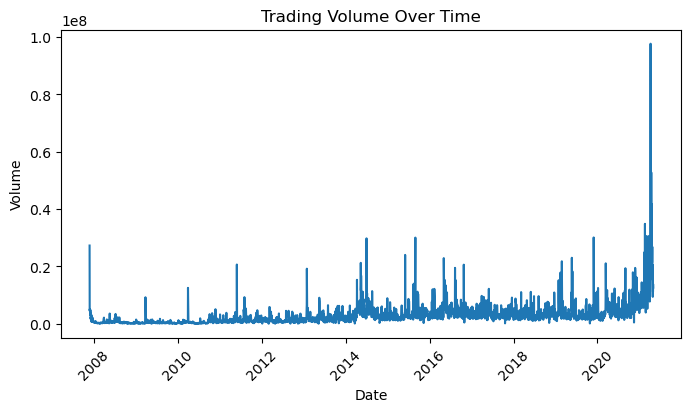

In [19]:
# Trading volume trend
plt.figure(figsize=(8,4))

# Line chart
plt.plot(df['Date'], df['Volume'])

# Chart title and labels
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45)

# Display chart
plt.show()

Trading volume analysis shows investor participation in the market.
High volume indicates increased trading activity and market interest.
Sudden spikes in volume may occur due to major financial or market events.
Volume trends help confirm the strength of stock price movements.

6: How volatile is the stock over time?

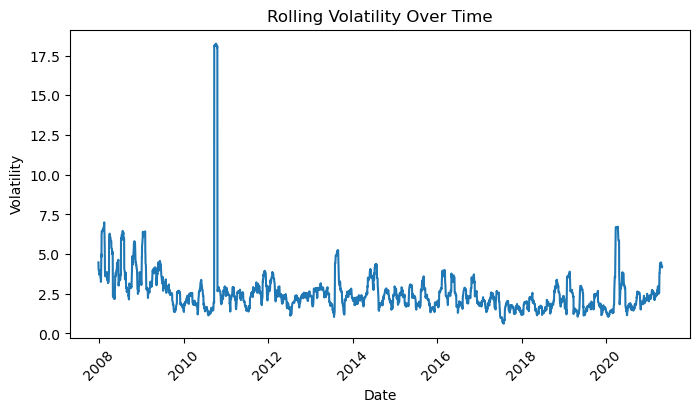

In [20]:
# Calculate rolling volatility
Volatility = Daily_Return.rolling(window=20).std()

# Create figure
plt.figure(figsize=(8,4))

# Line chart
plt.plot(df['Date'], Volatility)

# Chart title and labels
plt.title('Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.xticks(rotation=45)

# Display chart
plt.show()

Volatility measures the fluctuation or risk associated with the stock.
Higher volatility indicates unstable price movement.
Lower volatility indicates more stable stock performance.
Periods of high volatility may represent uncertain market conditions.

7: Are there any outliers or unusual spikes in stock prices?

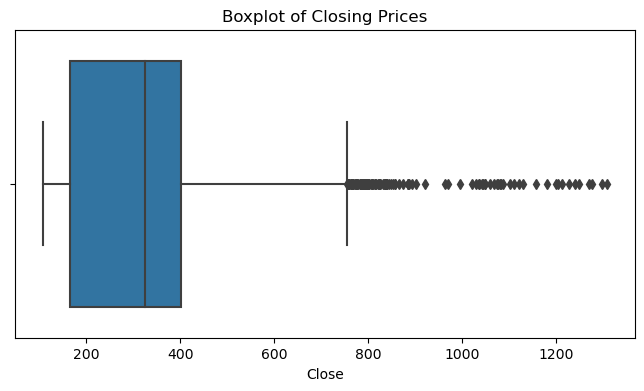

In [21]:
# Create figure
plt.figure(figsize=(8,4))

# Boxplot
sns.boxplot(x=df['Close'])

# Chart title
plt.title('Boxplot of Closing Prices')

# Display chart
plt.show()

The boxplot helps identify outliers in closing prices.
Points outside the whiskers represent unusual stock prices.
Outliers may occur due to sudden market events or extreme investor activity.
Detecting outliers is important for understanding abnormal market behavior.

8. Does the opening price have a relationship with the closing price?

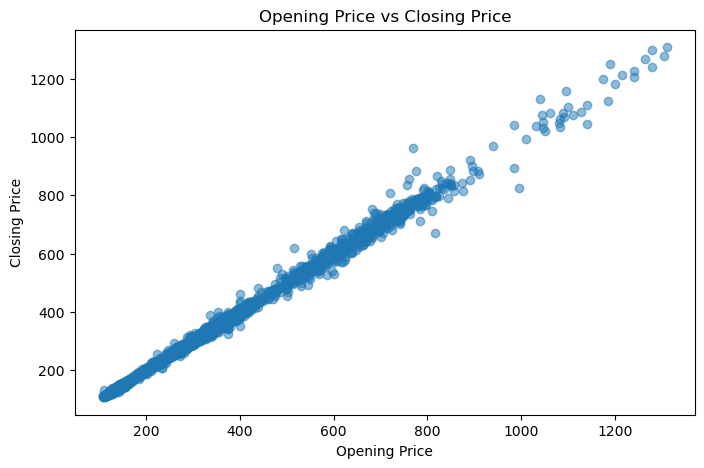

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(df['Open'], df['Close'], alpha=0.5)

plt.xlabel('Opening Price')
plt.ylabel('Closing Price')
plt.title('Opening Price vs Closing Price')
plt.show()

The scatter plot shows a strong positive relationship between the opening and closing prices. As the opening price increases, the closing price generally increases as well. This strong relationship supports the use of Open as an input feature for the regression models.

## **EDA Conclusion**

The analysis focused on understanding stock price trends, daily returns, trading volume, moving averages, volatility, and correlations between stock features.

The visualizations revealed important insights into market behavior, price fluctuations, investor activity, and risk patterns. Moving average and volatility analysis helped identify both short-term and long-term market trends, while the correlation analysis indicated strong relationships among the stock price variables. Overall, the exploratory data analysis provided a clear understanding of the dataset and established a solid foundation for building predictive machine learning models.

## **Data Preprocessing**

The Columns Prev_Close, Open, High, Low, Last are choosen as features and Close as target variable. Even though the independent features are correlated to each other showing multicolineariity we are taking these features because it has more corelation with target and our main objective is to predict the target, Closing Price.

In [29]:
df.head()

,Date,Symbol,Prev_Close,Open,High,Low,Last,Close,Vwap,Volume,Turnover,Trades,Deliverable_Volume,Deliverble
0,2007-11-27,MUNDRAPORT,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,35881.5,9859619,0.3612
1,2007-11-28,MUNDRAPORT,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,35881.5,1453278,0.3172
2,2007-11-29,MUNDRAPORT,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,35881.5,1069678,0.2088
3,2007-11-30,MUNDRAPORT,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,35881.5,1260913,0.2735
4,2007-12-03,MUNDRAPORT,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,35881.5,816123,0.2741


In [36]:
# Select features and target
#X = df.loc[:, ['Last','Vwap']].values
#X = df.loc[:, ['High','Last','Vwap']].values
X = df.loc[:, ['Prev_Close', 'Open', 'High', 'Low', 'Last']].values
#X = df.drop(columns=['Date','Close','Symbol']).values
y = df['Close'].values

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

## **Multiple Linear regression**

In [37]:
# Train model
regressor = LinearRegression()
regressor.fit(x_train, y_train)

# Make predictions
y_pred = regressor.predict(x_test)

# Model evaluation
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print("Mean:", df['Close'].mean())
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

# R² score
score = r2_score(y_test, y_pred)
print("r2 score is : %.2f" % (score * 100), "%")

Mean Absolute Error: 0.8905585084491743
Mean Squared Error: 2.437769590722621
Mean: 344.2016255267911
Root Mean Squared Error: 1.5613358353418463
r2 score is : 99.99 %


## **Polynomial Regression**

In [26]:
# Apply polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# Train model
regressor = LinearRegression()
regressor.fit(x_train_poly, y_train)

# Make predictions
y_pred = regressor.predict(x_test_poly)

# Model evaluation
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print("Mean:", df['Close'].mean())
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

# R² score
score = r2_score(y_test, y_pred)
print(f"R² Score: {score:.4f}")
print(f"Accuracy (R² × 100): {score*100:.2f}%")

Mean Absolute Error: 0.9059566201655486
Mean Squared Error: 2.4305583402983357
Mean: 344.2016255267911
Root Mean Squared Error: 1.5590248042601298
R² Score: 0.9999
Accuracy (R² × 100): 99.99%


In [38]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_train = pca.fit_transform(x_train)
X_test = pca.transform(x_test)

#Fitting Logistic Regression To the training set
from sklearn.linear_model import LinearRegression
classifier = LinearRegression()
classifier.fit(X_train, y_train)

# Predicting the test set result
# Predicting the test set result using
# predict function under LogisticRegression
y_pred = classifier.predict(X_test)


from sklearn.metrics import accuracy_score
# Model Accuracy, how often is the classifier correct?
#print("Accuracy:",r2_score(y_test, y_pred))
print(f"Accuracy:{r2_score(y_test, y_pred)*100:.2f}")

Accuracy:99.96


## **Model Performance Comparison**
#### Performance Metrics

| Metric | Multiple Linear Regression | Polynomial Regression (Degree = 2) | Better Model |
| -------- | -------- | -------- |-------- |
| Mean Absolute Error (MAE) | 0.8906 | 0.9060 | Multiple Linear Regression |
| Mean Squared Error (MSE) | 2.4378 | 2.4306 | Polynomial Regression |
| Root Mean Squared Error (RMSE) | 1.5613 | 1.5590  | Polynomial Regression |
| R² Score | 99.9944% | 99.9944% (≈99.99%) | Nearly Equal |


#### Final Model Selection
Although Polynomial Regression achieved marginally lower MSE and RMSE values, the improvement over Multiple Linear Regression was negligible. Considering its simpler structure, easier interpretation, lower computational complexity, and comparable predictive accuracy, **Multiple Linear Regression** was selected as the preferred model for this dataset.

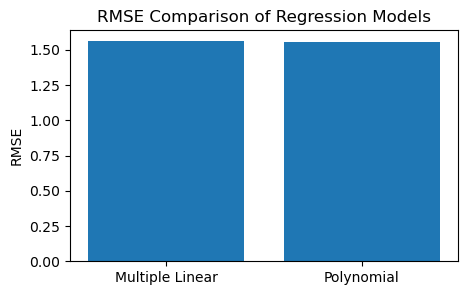

In [ ]:
# Model names and RMSE values
models = ['Multiple Linear', 'Polynomial']
rmse = [1.5613, 1.5590]

# Create figure
plt.figure(figsize=(5,3))

# Bar chart
plt.bar(models, rmse)

# Chart title and labels
plt.ylabel('RMSE')
plt.title('RMSE Comparison of Regression Models')

# Display chart
plt.show()

## **Conclusion**

Both Multiple Linear Regression and Polynomial Regression achieved excellent prediction accuracy, with an R² score of approximately 99.99%, indicating that both models were highly effective in predicting the stock closing price. Polynomial Regression achieved slightly lower MSE and RMSE values, suggesting a marginal improvement in capturing the relationship between the input features and the target variable. On the other hand, Multiple Linear Regression produced a slightly lower MAE, indicating marginally better average prediction accuracy.

Overall, the performance difference between the two models was negligible, implying that the relationship between the selected features and the closing price is largely linear. Therefore, Multiple Linear Regression is considered the preferred model for this dataset due to its simplicity, interpretability, computational efficiency, and performance comparable to Polynomial Regression. This makes it a more practical choice for stock closing price prediction on the given dataset.